# **Method-2 Knowledge Distillation**
* Knowledge distillation is a machine learning model compression technique where a small, compact "student" model is trained to reproduce the behavior, performance, and accuracy of a large, pre-trained "teacher" model.
* The pre-trained model has around 1.2 million parameters, and the transfer learning model also has a similar number of parameters. In real-world scenarios, this can lead to latency issues during inference, and we also need to load a larger model to perform the same task. What if we could have a model with the same capability but fewer parameters?


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import time
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# --- Hyperparameters ---
CONFIG = {
    "patch_len": 32,          # Length of each token (time steps)
    "d_model": 128,           # Hidden dimension (kept small for efficiency)
    "n_layers": 6,            # Number of Transformer blocks
    "n_heads": 4,             # Number of attention heads
    "d_ff": 512,              # Feed-forward dimension
    "dropout": 0.1,
    "context_len": 32,
    "batch_size": 64,
    "lr": 1e-3,
    "epochs": 5,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

print(f"Running on device: {CONFIG['device']}")

Running on device: cpu


In [ ]:
class WeatherPatchDataset(Dataset):
    def __init__(self, file_list, context_len=32):
        self.context_len = context_len
        self.data_chunks = []

        # Accept either a list of file paths OR a raw numpy/tensor array
        if isinstance(file_list, (np.ndarray, torch.Tensor)):
            arr = file_list if isinstance(file_list, np.ndarray) else file_list.numpy()
            if arr.ndim == 2:
                self.data_chunks.append(torch.from_numpy(arr.astype(np.float32)))
                print(f"Loaded array directly: {arr.shape}")
            else:
                print(f"Wrong shape {arr.shape}, expected 2D (N_patches, patch_len)")
        elif not hasattr(file_list, '__len__') or len(file_list) == 0:
            print("No files provided!")
        else:
            print(f"Loading {len(file_list)} files...")
            for f in file_list:
                try:
                    arr = np.load(f)
                    print(f"Loaded {os.path.basename(f)}: {arr.shape}")
                    if arr.ndim == 2:
                        self.data_chunks.append(torch.from_numpy(arr.astype(np.float32)))
                    else:
                        print(f"Skipping {f}, wrong shape {arr.shape}")
                except Exception as e:
                    print(f"Error loading {f}: {e}")

        # Build index map
        self.samples = []
        seq_len = context_len + 1
        for chunk_idx, chunk in enumerate(self.data_chunks):
            n = chunk.shape[0]
            if n < seq_len:
                continue
            for start in range(n - seq_len + 1):
                self.samples.append((chunk_idx, start))
        print(f"Total samples: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        chunk_idx, start_row = self.samples[idx]
        chunk = self.data_chunks[chunk_idx]

        window = chunk[start_row:start_row + self.context_len + 1]
        x = window[:-1]
        y = window[1:]
        return x, y

In [ ]:
class RMSNorm(nn.Module):
    """Root Mean Square Layer Normalization"""
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def forward(self, x):
        norm = torch.mean(x**2, dim=-1, keepdim=True)
        x_normed = x * torch.rsqrt(norm + self.eps)
        return self.scale * x_normed

class TimesFMLite(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.patch_embed = nn.Linear(config['patch_len'], config['d_model'])
        self.pos_embed = nn.Parameter(torch.zeros(1, config['context_len'], config['d_model']))
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=config['d_model'],
            nhead=config['n_heads'],
            dim_feedforward=config['d_ff'],
            dropout=config['dropout'],
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=config['n_layers'])
        self.norm_f = RMSNorm(config['d_model'])
        self.head = nn.Linear(config['d_model'], config['patch_len'])

    def forward(self, x):
        """
        Args:
            x: [Batch, Context_Len, Patch_Len]
        Returns:
            pred: [Batch, Context_Len, Patch_Len]
        """
        B, T, P = x.shape

        # Embed Patches
        x_emb = self.patch_embed(x) # [B, T, D]

        # Add Positional Encoding
        x_emb = x_emb + self.pos_embed[:, :T, :]

        # Causal Masking
        # Ensure position t can only attend to 0...t
        mask = torch.triu(torch.ones(T, T) * float('-inf'), diagonal=1).to(x.device)

        # 4. Transformer Pass
        # Note: TransformerDecoder normally takes memory from Encoder, but for Decoder-only (GPT style)
        # we just pass the tgt. Memory is ignored or passed as None depending on implementation.
        # PyTorch TransformerDecoder requires 'tgt' and optional 'memory'.
        # But actually, specific GPT usage usually uses TransformerEncoder structure with causal mask.
        # However, to avoid confusion, let's use the standard Causal logic: Tgt is the input.

        # We'll use the layers directly or the Decoder container locally.
        # For decoder-only, people often use TransformerEncoder with is_causal=True or mask.
        # Let's stick to the cleanest pyTorch implementation: TransformerEncoder with mask.
        # (Even though it's called 'Encoder', if you mask it, it's a Decoder).
        pass

class TimesFMLiteGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.patch_embed = nn.Linear(config['patch_len'], config['d_model'])
        self.pos_embed = nn.Parameter(torch.zeros(1, config['context_len'], config['d_model']))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config['d_model'],
            nhead=config['n_heads'],
            dim_feedforward=config['d_ff'],
            dropout=config['dropout'],
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=config['n_layers'])

        self.norm_f = RMSNorm(config['d_model'])
        self.head = nn.Linear(config['d_model'], config['patch_len'])

    def forward(self, x):
        # x: [Batch, Seq_Len, Patch_Len]
        B, T, P = x.shape

        # Embedding
        h = self.patch_embed(x)
        h = h + self.pos_embed[:, :T, :]
        mask = nn.Transformer.generate_square_subsequent_mask(T).to(x.device)

        # Blocks
        h = self.blocks(h, mask=mask, is_causal=True)

        # Output Projection
        h = self.norm_f(h)
        out = self.head(h)
        return out

In [ ]:
print("Initializing model...")
model = TimesFMLiteGPT(CONFIG).to(CONFIG["device"])

print("Loading trained weights...")
model_path = '/content/drive/MyDrive/weather_model_runs/best_model.pth'
model.load_state_dict(torch.load(model_path, map_location=CONFIG["device"]))

Initializing model...
Loading trained weights...


/tmp/ipykernel_157/1945507075.py:80: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=config['n_layers'])


<All keys matched successfully>

In [ ]:
model

TimesFMLiteGPT(
  (patch_embed): Linear(in_features=32, out_features=128, bias=True)
  (blocks): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm_f): RMSNorm()
  (head): Linear(in_features=128, out_features=32, bias=True)
)

# **Dataset Preparation**
* This is the most important part of knowledge distillation, how the data is been prepared for model training.
* In Knowledge Distillation, a soft label is the probability distribution over classes produced by the teacher model, rather than the hard ground-truth label.Soft labels contain more information than hard labels. It tells us how a particular temperature is anomaly or not this improves the generalization.

* ## Soft Label Preparation

  - The first requirement is the **predicted temperatures of all available patches**.
  - Consider a **series_id `<a,b>`** and collect all its temperature values. Then apply a **sliding window of size 32 with a stride of 1**.
  - Use these patch values to obtain the **predicted patch**. Meanwhile, keep track of the **mean and standard deviation of both the input and predicted patches**, as well as the **immediate next value for a given patch**.
  - Normalize both the **actual** and **predicted patches**.
  - The **soft label** is generated using the following formula:
      - score = (actual_33rd - predicted_mean)/(actual_std)

      - As seen above, the formula uses the **statistics of both the actual and predicted patches**. Although we could use only the predicted statistics, incorporating both behaviors helps generate a **richer soft label for the actual 33rd value**. After getting score take sigmoid of it to get a probability whether that point is anomaly or not.

* ## Hard Label Preparation
  - Take **all the predicted patches for a particular `series_id`**.
  - Compute the **99th percentile** and **1st percentile** of the predicted patches.
  - Any values that **fall outside this range are considered anomalies**.
  - Assign:
    - **1 → Anomaly**
    - **0 → Normal**

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
metadata = pd.read_parquet('/content/drive/MyDrive/patches_weather_data/weather_part_1_metadata.parquet')
patches = np.load('/content/drive/MyDrive/patches_weather_data/weather_part_1_patches.npy')

metadata.shape, patches.shape

((801450, 2), (801450, 32))

In [ ]:
all_series_ids = metadata['series_id'].unique()
print(f"Total series: {len(all_series_ids)}")

Total series: 2925


In [ ]:
def create_dataset_for_series(model, patches, series_id, config):
    context_len = config['context_len']  # 32
    patch_len = config['patch_len']

    concat_ts = patches.flatten()
    total_ts = len(concat_ts)
    print(f"Total time steps: {total_ts}")

    n_patches = context_len // patch_len
    usable_ts = n_patches * patch_len
    n_windows = len(range(0, total_ts - context_len - 1, 32))
    print(f"Expected number of windows: {n_windows}")

    rows = []
    for sample_idx in range(0,total_ts - context_len,32):
        # Step 1: Raw context window and actual 33rd value
        context_window = concat_ts[sample_idx : sample_idx + context_len]   # (32,)
        actual_33rd    = concat_ts[sample_idx + context_len]                 # scalar

        # Step 2: Mean and std of raw context
        actual_mean = np.mean(context_window)
        actual_std  = np.std(context_window) + 1e-8

        # Step 3: Normalize context window
        normalized_context = (context_window - actual_mean) / actual_std     # (32,)

        # Step 4: Reshape normalized context into patches for model
        model_input = context_window[:usable_ts].reshape(n_patches, patch_len)

        # Step 5: Get model predictions
        model.eval()
        with torch.no_grad():
            x = torch.from_numpy(model_input.astype(np.float32)).unsqueeze(0).to(config['device'])
            out = model(x)                                                   # [1, n_patches, patch_len]
            predicted_patches = out[0].cpu().numpy()                         # (n_patches, patch_len)

        # Step 6: Mean of last predicted patch
        predicted_next_patch = predicted_patches[-1]                         # (patch_len,)
        predicted_mean = float(np.mean(predicted_next_patch))

        # Step 7: Soft label = sigmoid((normalized_33rd - predicted_mean) / actual_std)
        score = (actual_33rd - predicted_mean) / float(actual_std)
        soft_label = float(torch.sigmoid(torch.tensor(score)).item())

        window_id = f"{series_id}_w{sample_idx:05d}"

        row = {
            'window_id': window_id,
            'series_id': series_id,
            'window_start': sample_idx,
            'window_end': sample_idx + context_len - 1,
            'context_window': [round(v, 4) for v in context_window.tolist()],
            'normalized_context': [round(v, 4) for v in normalized_context.tolist()],
            'actual_mean': round(float(actual_mean), 4),
            'actual_std': round(float(actual_std), 4),
            'actual_33rd': round(float(actual_33rd), 4),
            'predicted_patches': [[round(v, 4) for v in patch] for patch in predicted_patches.tolist()],
            'predicted_mean': round(predicted_mean, 4),
            'soft_label': round(soft_label, 4)
        }
        rows.append(row)

    print(f"Total samples created: {len(rows)}")
    return rows

In [ ]:
# --- Run ---
series_id = '<10.0, 68.0>'
indices = metadata[metadata['series_id'] == series_id]['patch_idx'].values
req_patches = patches[indices]

rows = create_dataset_for_series(model, req_patches, series_id, CONFIG)

df = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.4f}'.format)
print(f"\nDataset shape: {df.shape}")

Total time steps: 8768
Expected number of windows: 273
Total samples created: 273

Dataset shape: (273, 12)


In [ ]:
df.head()

,window_id,series_id,window_start,window_end,context_window,normalized_context,actual_mean,actual_std,actual_33rd,predicted_patches,predicted_mean,soft_label
0,"<10.0, 68.0>_w00000","<10.0, 68.0>",0,31,"[-2.6348, -2.7363, -1.459, -1.2656, -0.5576, 4...","[-0.5784, -0.6044, -0.2779, -0.2285, -0.0475, ...",-0.3718,3.9123,6.8594,"[[8.9458, 8.8252, 6.3138, 5.9645, 5.449, 5.118...",2.1290,0.7701
1,"<10.0, 68.0>_w00032","<10.0, 68.0>",32,63,"[6.8594, 8.0703, 9.25, 8.2109, 7.2539, 5.2969,...","[1.1906, 1.4629, 1.7281, 1.4945, 1.2793, 0.839...",1.5636,4.4479,-1.8789,"[[-2.4009, -3.1435, -3.0527, -3.0362, -4.2563,...",-1.8117,0.4962
2,"<10.0, 68.0>_w00064","<10.0, 68.0>",64,95,"[-1.8789, -2.6758, -3.2793, -3.6172, -5.2617, ...","[0.1055, -0.0934, -0.2441, -0.3284, -0.739, -0...",-2.3015,4.0059,-6.3438,"[[-6.9143, -6.924, -6.23, -5.2283, -3.8821, 0....",-1.8109,0.2439
3,"<10.0, 68.0>_w00096","<10.0, 68.0>",96,127,"[-6.3438, -6.1641, -5.668, -4.9531, -4.0039, 1...","[-1.0339, -0.9949, -0.8871, -0.7318, -0.5257, ...",-1.5837,4.6040,3.9121,"[[5.7062, 6.1267, 6.0107, 5.6281, 4.863, 4.083...",1.3372,0.6363
4,"<10.0, 68.0>_w00128","<10.0, 68.0>",128,159,"[3.9121, 5.9258, 7.2969, 6.875, 5.7852, 3.668,...","[0.4776, 0.9238, 1.2276, 1.1341, 0.8927, 0.423...",1.7565,4.5130,2.7422,"[[1.6123, 1.2008, 1.3312, 1.3474, 0.4324, 0.35...",2.9149,0.4904


In [ ]:
df.shape

(273, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   window_id           273 non-null    object 
 1   series_id           273 non-null    object 
 2   window_start        273 non-null    int64  
 3   window_end          273 non-null    int64  
 4   context_window      273 non-null    object 
 5   normalized_context  273 non-null    object 
 6   actual_mean         273 non-null    float64
 7   actual_std          273 non-null    float64
 8   actual_33rd         273 non-null    float64
 9   predicted_patches   273 non-null    object 
 10  predicted_mean      273 non-null    float64
 11  soft_label          273 non-null    float64
dtypes: float64(5), int64(2), object(5)
memory usage: 25.7+ KB


In [ ]:
df['soft_label'].describe()

,soft_label
count,273.0000
mean,0.4953
std,0.2259
min,0.0989
25%,0.2319
50%,0.5645
75%,0.7002
max,0.8595


In [ ]:
# df['predicted_patches'].values[2][0]
combined = []
for row in df['predicted_patches'].values:
    combined.extend(row[0])
q99 = np.quantile(combined, 0.99)

In [ ]:
df['hard_label'] = df['actual_33rd'].apply(lambda x: 1 if x > q99 else 0)
df.head()

,window_id,series_id,window_start,window_end,context_window,normalized_context,actual_mean,actual_std,actual_33rd,predicted_patches,predicted_mean,soft_label,hard_label
0,"<10.0, 68.0>_w00000","<10.0, 68.0>",0,31,"[-2.6348, -2.7363, -1.459, -1.2656, -0.5576, 4...","[-0.5784, -0.6044, -0.2779, -0.2285, -0.0475, ...",-0.3718,3.9123,6.8594,"[[8.9458, 8.8252, 6.3138, 5.9645, 5.449, 5.118...",2.1290,0.7701,0
1,"<10.0, 68.0>_w00032","<10.0, 68.0>",32,63,"[6.8594, 8.0703, 9.25, 8.2109, 7.2539, 5.2969,...","[1.1906, 1.4629, 1.7281, 1.4945, 1.2793, 0.839...",1.5636,4.4479,-1.8789,"[[-2.4009, -3.1435, -3.0527, -3.0362, -4.2563,...",-1.8117,0.4962,0
2,"<10.0, 68.0>_w00064","<10.0, 68.0>",64,95,"[-1.8789, -2.6758, -3.2793, -3.6172, -5.2617, ...","[0.1055, -0.0934, -0.2441, -0.3284, -0.739, -0...",-2.3015,4.0059,-6.3438,"[[-6.9143, -6.924, -6.23, -5.2283, -3.8821, 0....",-1.8109,0.2439,0
3,"<10.0, 68.0>_w00096","<10.0, 68.0>",96,127,"[-6.3438, -6.1641, -5.668, -4.9531, -4.0039, 1...","[-1.0339, -0.9949, -0.8871, -0.7318, -0.5257, ...",-1.5837,4.6040,3.9121,"[[5.7062, 6.1267, 6.0107, 5.6281, 4.863, 4.083...",1.3372,0.6363,0
4,"<10.0, 68.0>_w00128","<10.0, 68.0>",128,159,"[3.9121, 5.9258, 7.2969, 6.875, 5.7852, 3.668,...","[0.4776, 0.9238, 1.2276, 1.1341, 0.8927, 0.423...",1.7565,4.5130,2.7422,"[[1.6123, 1.2008, 1.3312, 1.3474, 0.4324, 0.35...",2.9149,0.4904,0


In [ ]:
df['hard_label'].value_counts()

,count
hard_label,
0,270
1,3


In [ ]:
def create_dataset_for_series(model, patches, series_id, config):
    context_len = config['context_len']  # 32
    patch_len = config['patch_len']

    concat_ts = patches.flatten()
    total_ts = len(concat_ts)
    print(f"Total time steps: {total_ts}")

    n_patches = context_len // patch_len
    usable_ts = n_patches * patch_len

    rows = []
    for sample_idx in range(0,total_ts - context_len,32):
        # Step 1: Raw context window and actual 33rd value
        context_window = concat_ts[sample_idx : sample_idx + context_len]
        actual_33rd    = concat_ts[sample_idx + context_len]

        # Step 2: Mean and std of raw context
        actual_mean = np.mean(context_window)
        actual_std  = np.std(context_window) + 1e-8

        # Step 3: Normalize context window
        normalized_context = (context_window - actual_mean) / actual_std

        # Step 4: Reshape normalized context into patches for model
        model_input = context_window[:usable_ts].reshape(n_patches, patch_len)

        # Step 5: Get model predictions
        model.eval()
        with torch.no_grad():
            x = torch.from_numpy(model_input.astype(np.float32)).unsqueeze(0).to(config['device'])
            out = model(x)
            predicted_patches = out[0].cpu().numpy()

        # Mean of last predicted patch
        predicted_next_patch = predicted_patches[-1]
        predicted_mean = float(np.mean(predicted_next_patch))

        score = (actual_33rd - predicted_mean) / float(actual_std)
        soft_label = float(torch.sigmoid(torch.tensor(score)).item())

        window_id = f"{series_id}_w{sample_idx:05d}"

        row = {
            'window_id': window_id,
            'series_id': series_id,
            'window_start': sample_idx,
            'window_end': sample_idx + context_len - 1,
            'context_window': [round(v, 4) for v in context_window.tolist()],
            'normalized_context': [round(v, 4) for v in normalized_context.tolist()],
            'actual_mean': round(float(actual_mean), 4),
            'actual_std': round(float(actual_std), 4),
            'actual_33rd': round(float(actual_33rd), 4),
            'predicted_patches': [[round(v, 4) for v in patch] for patch in predicted_patches.tolist()],
            'predicted_mean': round(predicted_mean, 4),
            'soft_label': round(soft_label, 4)
        }
        rows.append(row)

    print(f"Total samples created: {len(rows)}")
    return rows

In [ ]:
def process_all_files(model, config, base_path, output_dir, n_files=5):
    os.makedirs(output_dir, exist_ok=True)

    for file_idx in range(4, n_files + 1): #change afterwards from 3 to 1
        metadata_path = f'{base_path}/weather_part_{file_idx}_metadata.parquet'
        patches_path  = f'{base_path}/weather_part_{file_idx}_patches.npy'

        print(f"\n{'='*60}")
        print(f"Processing file {file_idx}/5")
        print(f"{'='*60}")

        metadata = pd.read_parquet(metadata_path)
        patches  = np.load(patches_path)

        all_series = metadata['series_id'].unique()
        print(f"Found {len(all_series)} unique series in file {file_idx}")

        all_rows = []
        for s_idx, series_id in enumerate(all_series):

            indices = metadata[metadata['series_id'] == series_id]['patch_idx'].values
            req_patches = patches[indices]

            if len(req_patches) <= config['context_len'] // config['patch_len']:
                print(f"  Skipping {series_id} — not enough patches")
                continue

            rows = create_dataset_for_series(model, req_patches, series_id, config)
            all_rows.extend(rows)

        # Build dataframe
        df = pd.DataFrame(all_rows)

        # Compute q99 across all predicted patches in this file and assign hard label
        combined = []
        for row in df['predicted_patches'].values:
            for patch in row:
                combined.extend(patch)

        combined = np.array(combined)

        q99 = np.quantile(combined, 0.99)
        q01 = np.quantile(combined, 0.01)

        print(f"\nFile {file_idx} — Q99 threshold: {q99:.4f}")
        print(f"File {file_idx} — Q01 threshold: {q01:.4f}")

        df['hard_label'] = df['actual_33rd'].apply(
            lambda x: 1 if (x > q99 or x < q01) else 0
        )

        print(f"Hard label distribution:\n{df['hard_label'].value_counts().to_string()}")
        print(f"Total rows: {len(df)}")

        # Save to parquet
        out_path = os.path.join(output_dir, f'distillation_part_{file_idx}.parquet')
        df.to_parquet(out_path, index=False)
        print(f"Saved -> {out_path}")

    print(f"\nAll files processed. Outputs in: {output_dir}")

In [ ]:
# --- Run ---
BASE_PATH   = '/content/drive/MyDrive/patches_weather_data'
OUTPUT_DIR  = '/content/drive/MyDrive/distillation_dataset2'

process_all_files(model, CONFIG, BASE_PATH, OUTPUT_DIR, n_files=5)

Saved -> /content/drive/MyDrive/distillation_dataset2/distillation_part_5.parquet

All files processed. Outputs in: /content/drive/MyDrive/distillation_dataset2


In [ ]:
distilled = pd.read_parquet('/content/drive/MyDrive/distillation_dataset2/distillation_part_2.parquet')
distilled.head()

,window_id,series_id,window_start,window_end,context_window,normalized_context,actual_mean,actual_std,actual_33rd,predicted_patches,predicted_mean,soft_label,hard_label
0,"<24.75, 68.0>_w00000","<24.75, 68.0>",0,31,"[9.2422, 9.0625, 9.0781, 9.6797, 12.5312, 20.1...","[-1.2654, -1.2975, -1.2947, -1.1873, -0.6782, ...",16.3301,5.6012,21.0312,"[[23.0371, 23.998, 23.7364, 23.6223, 23.104, 2...",18.1448,0.6261,0
1,"<24.75, 68.0>_w00032","<24.75, 68.0>",32,63,"[21.0312, 23.5156, 23.1406, 23.0, 22.625, 20.6...","[0.6512, 1.0879, 1.022, 0.9973, 0.9314, 0.5771...",17.3264,5.6889,17.3281,"[[16.7569, 14.8656, 14.2337, 13.8436, 12.2035,...",16.3136,0.5445,0
2,"<24.75, 68.0>_w00064","<24.75, 68.0>",64,95,"[17.3281, 16.5625, 15.8828, 15.3203, 14.2031, ...","[0.2268, 0.0354, -0.1345, -0.2752, -0.5545, -0...",16.4209,3.9993,11.5156,"[[10.596, 10.5153, 10.6209, 11.4786, 12.6606, ...",15.8850,0.2511,0
3,"<24.75, 68.0>_w00096","<24.75, 68.0>",96,127,"[11.5156, 10.7891, 10.4766, 10.7031, 11.1172, ...","[-0.8089, -0.9754, -1.047, -0.9951, -0.9002, 0...",15.0461,4.3644,20.5625,"[[22.8234, 23.6291, 23.8369, 23.7102, 23.182, ...",17.9378,0.6460,0
4,"<24.75, 68.0>_w00128","<24.75, 68.0>",128,159,"[20.5625, 23.3281, 23.1719, 23.1094, 22.9844, ...","[0.5765, 1.1511, 1.1187, 1.1057, 1.0797, 0.712...",17.7881,4.8127,16.3438,"[[16.4204, 15.1992, 14.8711, 14.7035, 13.1526,...",16.7817,0.4773,0


In [ ]:
distilled['series_id'].unique()

array(['<24.75, 68.0>', '<24.75, 68.25>', '<24.75, 68.5>', ...,
       '<30.75, 96.5>', '<30.75, 96.75>', '<30.75, 97.0>'], dtype=object)

In [ ]:
distilled['hard_label'].value_counts()

,count
hard_label,
0,781615
1,16910


In [ ]:
distilled[distilled['hard_label'] == 1]

,window_id,series_id,window_start,window_end,context_window,normalized_context,actual_mean,actual_std,actual_33rd,predicted_patches,predicted_mean,soft_label,hard_label
90,"<24.75, 68.0>_w02880","<24.75, 68.0>",2880,2911,"[27.0781, 26.5625, 27.25, 28.3594, 31.1562, 34...","[-1.0986, -1.2023, -1.0641, -0.8409, -0.2784, ...",32.5405,4.9720,40.7812,"[[40.7773, 41.3224, 41.1998, 41.2064, 41.3701,...",35.7031,0.7352,1
102,"<24.75, 68.0>_w03264","<24.75, 68.0>",3264,3295,"[26.4531, 26.6094, 28.1875, 29.0781, 29.9844, ...","[-1.2037, -1.1693, -0.822, -0.6261, -0.4267, 0...",31.9233,4.5446,40.8125,"[[40.2282, 40.5027, 39.8017, 39.6625, 39.0232,...",34.0641,0.8153,1
123,"<24.75, 68.0>_w03936","<24.75, 68.0>",3936,3967,"[28.4844, 28.5625, 28.9062, 32.5938, 33.5312, ...","[-1.7201, -1.6981, -1.6012, -0.5625, -0.2984, ...",34.5903,3.5498,40.7812,"[[40.1088, 40.6715, 39.7194, 39.2996, 38.6673,...",35.3721,0.8211,1
363,"<24.75, 68.25>_w02880","<24.75, 68.25>",2880,2911,"[27.2031, 26.5469, 27.4531, 28.5625, 31.3281, ...","[-1.0248, -1.1554, -0.9751, -0.7543, -0.2039, ...",32.3525,5.0247,40.7188,"[[40.6591, 41.2319, 41.0364, 41.0474, 41.0657,...",35.3695,0.7436,1
375,"<24.75, 68.25>_w03264","<24.75, 68.25>",3264,3295,"[26.5469, 26.6719, 28.2812, 29.0938, 30.0938, ...","[-1.1876, -1.1611, -0.8206, -0.6486, -0.437, 0...",32.1587,4.7254,41.2188,"[[40.6428, 40.9461, 40.2386, 40.1012, 39.5096,...",34.3217,0.8115,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
798506,"<30.75, 97.0>_w08128","<30.75, 97.0>",8128,8159,"[-15.8984, -16.2656, -17.9062, -19.4375, -20.7...","[0.2023, 0.1221, -0.2363, -0.5708, -0.8677, -1...",-16.8245,4.5779,-23.5156,"[[-23.9019, -23.4631, -18.8606, -16.2883, -13....",-15.8142,0.1568,1
798512,"<30.75, 97.0>_w08320","<30.75, 97.0>",8320,8351,"[-15.5312, -16.4531, -16.4688, -16.4531, -17.6...","[0.5538, 0.2298, 0.2243, 0.2298, -0.2041, -0.3...",-17.1069,2.8450,-22.3438,"[[-24.3896, -24.684, -22.1617, -20.6414, -19.9...",-21.1830,0.3994,1
798517,"<30.75, 97.0>_w08480","<30.75, 97.0>",8480,8511,"[-10.8281, -10.9844, -13.0547, -14.3125, -14.9...","[1.4716, 1.4356, 0.9593, 0.6699, 0.5225, 0.398...",-17.2241,4.3464,-20.9531,"[[-19.4198, -20.6518, -20.5589, -20.9972, -22....",-18.7682,0.3769,1
798518,"<30.75, 97.0>_w08512","<30.75, 97.0>",8512,8543,"[-20.9531, -20.875, -20.25, -21.9062, -23.0938...","[-0.5276, -0.5115, -0.3824, -0.7244, -0.9696, ...",-18.3982,4.8426,-23.2969,"[[-23.8248, -23.4704, -18.9434, -16.2984, -13....",-14.8814,0.1496,1


In [ ]:
distilled[distilled['series_id'] == '<31.0, 68.0>'].head()

,window_id,series_id,window_start,window_end,context_window,normalized_context,actual_mean,actual_std,actual_33rd,predicted_patches,predicted_mean,soft_label,hard_label
0,"<31.0, 68.0>_w00000","<31.0, 68.0>",0,31,"[-2.6348, -2.7363, -1.459, -1.2656, -0.5576, 4...","[-0.5784, -0.6044, -0.2779, -0.2285, -0.0475, ...",-0.3718,3.9123,6.8594,"[[8.9449, 8.8247, 6.3121, 5.9631, 5.4472, 5.11...",2.1285,0.7702,0
1,"<31.0, 68.0>_w00032","<31.0, 68.0>",32,63,"[6.8594, 8.0703, 9.25, 8.2109, 7.2539, 5.2969,...","[1.1906, 1.4629, 1.7281, 1.4945, 1.2793, 0.839...",1.5636,4.4479,-1.8789,"[[-2.401, -3.1437, -3.0535, -3.0372, -4.2579, ...",-1.8134,0.4963,0
2,"<31.0, 68.0>_w00064","<31.0, 68.0>",64,95,"[-1.8789, -2.6758, -3.2793, -3.6172, -5.2617, ...","[0.1055, -0.0934, -0.2441, -0.3284, -0.739, -0...",-2.3015,4.0059,-6.3438,"[[-6.9157, -6.9255, -6.2313, -5.2293, -3.8834,...",-1.8121,0.2439,0
3,"<31.0, 68.0>_w00096","<31.0, 68.0>",96,127,"[-6.3438, -6.1641, -5.668, -4.9531, -4.0039, 1...","[-1.0339, -0.9949, -0.8871, -0.7318, -0.5257, ...",-1.5837,4.6040,3.9121,"[[5.7069, 6.128, 6.0125, 5.6301, 4.865, 4.0851...",1.3399,0.6361,0
4,"<31.0, 68.0>_w00128","<31.0, 68.0>",128,159,"[3.9121, 5.9258, 7.2969, 6.875, 5.7852, 3.668,...","[0.4776, 0.9238, 1.2276, 1.1341, 0.8927, 0.423...",1.7565,4.5130,2.7422,"[[1.6141, 1.202, 1.3322, 1.3476, 0.4312, 0.349...",2.9145,0.4905,0


In [ ]:
distilled[distilled['series_id'] == '<37.0, 97.0>'].head()

,window_id,series_id,window_start,window_end,context_window,normalized_context,actual_mean,actual_std,actual_33rd,predicted_patches,predicted_mean,soft_label,hard_label
798252,"<37.0, 97.0>_w00000","<37.0, 97.0>",0,31,"[-21.2344, -20.7656, -17.0312, -15.0703, -13.1...","[-2.3709, -2.2663, -1.433, -0.9955, -0.5632, 0...",-10.6086,4.4818,-4.4219,"[[-3.906, -3.79, -6.5619, -7.0468, -7.4604, -8...",-10.5547,0.7971,0
798253,"<37.0, 97.0>_w00032","<37.0, 97.0>",32,63,"[-4.4219, -5.1328, -7.9102, -8.8594, -8.9141, ...","[1.2997, 1.1531, 0.5804, 0.3847, 0.3734, 0.194...",-10.7250,4.8496,-9.6641,"[[-9.6732, -11.295, -11.6758, -12.1543, -13.62...",-11.2757,0.5823,0
798254,"<37.0, 97.0>_w00064","<37.0, 97.0>",64,95,"[-9.6641, -10.5859, -11.0234, -11.6953, -12.78...","[0.2921, 0.0637, -0.0447, -0.2112, -0.4802, -0...",-10.8429,4.0363,-19.1094,"[[-18.6118, -18.3194, -13.8575, -12.3938, -11....",-11.7855,0.1401,0
798255,"<37.0, 97.0>_w00096","<37.0, 97.0>",96,127,"[-19.1094, -19.0625, -12.5312, -11.9688, -10.8...","[-2.0805, -2.0686, -0.415, -0.2726, 0.0102, 1....",-10.8920,3.9498,-3.0879,"[[-3.7512, -4.1024, -7.6367, -8.5691, -8.9801,...",-10.7321,0.8738,0
798256,"<37.0, 97.0>_w00128","<37.0, 97.0>",128,159,"[-3.0879, -2.8301, -8.2422, -9.625, -9.9844, -...","[1.8647, 1.9243, 0.6729, 0.3532, 0.2701, 0.127...",-11.1524,4.3249,-12.8750,"[[-12.3739, -13.7795, -13.9151, -14.1505, -15....",-12.3887,0.4719,0


In [ ]:
distilled[distilled['series_id'] == '<31.0, 68.0>']['predicted_patches'].values

In [ ]:
distilled['soft_label'].describe()

,soft_label
count,798525.000000
mean,0.495272
std,0.225524
min,0.098900
25%,0.231900
50%,0.564500
75%,0.700200
max,0.859500


In [ ]:
unique_series_ids = distilled['series_id'].unique()
temp = 0

for series_id in unique_series_ids:
  combined = []
  for row in distilled[distilled['series_id'] == series_id]['predicted_patches'].values:
    for patch in row:
      combined.extend(patch)
  q99 = np.quantile(combined, 0.99)
  temp += q99

threshold = temp / len(unique_series_ids)
print(f"Threshold: {threshold}")

Threshold: 33.726664999998604


In [ ]:
combined = []
for row in distilled['predicted_patches'].values:
    for patch in row:
        combined.extend(patch)
q99 = np.quantile(combined, 0.99)

In [ ]:
q99

np.float64(33.7421)

# **Model Building**
* A multi-layer neural network is used here for training the model to predict only the soft labels, loss function used is **huber-loss**.
* Currently, only 2013 data is used for training the model later other years data will also be used for training the model.
* For 2013 data I have segregated the dataset that was prepared in the before steps into 5 parquet files 3 files are used for training 1 for validation and the last one for testing. Thus, total training samples are **2,395,575**.
* The parameters of distilled model is **94,401**.

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
CONFIG = {
    # Data
    "data_dir" : "/content/drive/MyDrive/distillation_dataset2",
    "save_dir" : "/content/drive/MyDrive/distillation_dataset2",
    "save_path": "/content/drive/MyDrive/distillation_dataset2/best_student_mlp.pt",

    # Model
    "window_size" : 32,
    "hidden_dims" : [512, 128, 64, 32],
    "dropout"     : 0.2,

    # Training
    "epochs"      : 10,
    "batch_size"  : 256,
    "lr"          : 5e-4,
    "weight_decay": 1e-3,

    # Loss
    "alpha": 0.65,
    "label_smoothing": 0.05,

    # Scheduler
    "lr_patience" : 3,
    "lr_factor"   : 0.5,
    "lr_min"      : 1e-6,
    "huber_delta": 1.0,

    'threshold':0.9,
    "pos_weight"  : 81.0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

print(f"Device         : {CONFIG['device']}")
print(f"Hidden dims    : {CONFIG['hidden_dims']}")
print(f"Dropout        : {CONFIG['dropout']}")
print(f"Weight decay   : {CONFIG['weight_decay']}")
print(f"LR             : {CONFIG['lr']}")
print(f"Label smoothing: {CONFIG['label_smoothing']}")
print(f"Alpha          : {CONFIG['alpha']}")

# Make sure save dir exists
os.makedirs(CONFIG["save_dir"], exist_ok=True)

In [ ]:
class DistillationDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.X = torch.tensor(
                          np.stack(df["context_window"].values),
                          dtype=torch.float32)
        self.y_soft = torch.tensor(df["soft_label"].values, dtype=torch.float32)
        self.y_hard = torch.tensor(df["hard_label"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_soft[idx], self.y_hard[idx]


def load_parquet_files(data_dir: str, file_indices: list) -> pd.DataFrame:
    dfs = []
    for i in file_indices:
        path = os.path.join(data_dir, f"distillation_part_{i}.parquet")
        if not os.path.exists(path):
            print(f"  [WARN] File {path} not found. Skipping...")
            continue
        df   = pd.read_parquet(path)
        print(f"  Loaded part_{i}: {len(df):>10,} rows")
        dfs.append(df)

    if len(dfs) == 0:
        raise ValueError("No files loaded. Check data directory.")

    combined = pd.concat(dfs, ignore_index=True)
    n_pos = int((combined["hard_label"] == 1).sum())
    n_neg = int((combined["hard_label"] == 0).sum())
    print(f"  {'─'*38}")
    print(f"  Total    : {len(combined):>10,} rows")
    print(f"  Anomaly  : {n_pos:>10,}  ({100*n_pos/len(combined):.3f}%)")
    print(f"  Normal   : {n_neg:>10,}  ({100*n_neg/len(combined):.3f}%)\n")
    return combined

In [ ]:
class MLPStudentModel(nn.Module):
    def __init__(self, window_size: int = 32, hidden_dims: list = None, dropout: float = 0.2):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [64, 32]

        layer_sizes = [window_size] + hidden_dims
        layers      = []

        for i in range(len(layer_sizes) - 1):
            in_dim  = layer_sizes[i]
            out_dim = layer_sizes[i + 1]
            layers += [
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]

        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.net(x)).squeeze(-1)

In [ ]:
class CombinedDistillationLoss(nn.Module):
    """
    L_total = Huber(student_prob, soft_label)

    Changes vs previous version
    ───────────────────────────
    - Removed BCE (hard label) component entirely
    - Removed alpha weighting — only soft distillation loss remains
    - pos_weight no longer needed
    """

    def __init__(self, huber_delta: float = 1.0):
        super().__init__()
        self.huber_delta = huber_delta

    def forward(self, probs, y_soft, y_hard=None):  # y_hard kept for API compatibility
        l_soft = F.huber_loss(probs, y_soft, delta=self.huber_delta)
        return l_soft, l_soft.item(), 0.0  # 0.0 placeholder for hard loss

In [ ]:
def evaluate(model, loader, criterion, device):
    """
    Probability-based metrics only:
        loss    : combined distillation loss
        roc_auc : threshold-independent discrimination ability
        pr_auc  : precision-recall AUC — key for imbalanced anomaly data
    """
    model.eval()
    all_probs, all_hard = [], []
    total_loss = 0.0

    with torch.no_grad():
        for X, y_soft, y_hard in loader:
            X, y_soft, y_hard = X.to(device), y_soft.to(device), y_hard.to(device)
            probs = model(X)
            loss, _, _ = criterion(probs, y_soft, y_hard)
            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_hard.extend(y_hard.cpu().numpy())

    all_probs = np.array(all_probs)
    all_hard  = np.array(all_hard).astype(int)

    return {
        "loss"   : round(total_loss / len(loader), 5),
    }


def print_metrics(split: str, metrics: dict):
    print(f"\n  {'─'*45}")
    print(f"  {split.upper()}")
    print(f"  {'─'*45}")
    for k, v in metrics.items():
        print(f"    {k:<12}: {v}")
    print(f"  {'─'*45}")

In [ ]:
def get_probs(model, loader, device):
    """Collect all probabilities and true labels from a loader."""
    model.eval()
    all_probs, all_hard = [], []
    with torch.no_grad():
        for X, y_soft, y_hard in loader:
            probs = model(X.to(device))
            all_probs.extend(probs.cpu().numpy())
            all_hard.extend(y_hard.numpy())
    return np.array(all_probs), np.array(all_hard).astype(int)


def apply_threshold(model, loader, device, threshold, split_name):
    """
    Apply fixed threshold to segment probabilities into anomaly/normal.
    Probability >= threshold → Anomaly (1)
    Probability <  threshold → Normal  (0)
    """
    probs, labels = get_probs(model, loader, device)
    preds         = (probs >= threshold).astype(int)
    n_anomaly     = preds.sum()
    n_normal      = len(preds) - n_anomaly

    print(f"\n  {'─'*50}")
    print(f"  {split_name.upper()}  (threshold={threshold:.4f})")
    print(f"  {'─'*50}")
    print(f"  Probability distribution:")
    print(f"    Min    : {probs.min():.4f}")
    print(f"    Mean   : {probs.mean():.4f}")
    print(f"    Median : {np.median(probs):.4f}")
    print(f"    P95    : {np.percentile(probs, 95):.4f}")
    print(f"    Max    : {probs.max():.4f}")
    print(f"  Segmentation:")
    print(f"    Anomaly: {n_anomaly:>8,}  ({100*n_anomaly/len(preds):.3f}%)")
    print(f"    Normal : {n_normal:>8,}  ({100*n_normal/len(preds):.3f}%)")
    print(f"  {'─'*50}")

    return probs, preds

In [ ]:
def train(config: dict):
    device = config["device"]

    # ── Load Data ─────────────────────────────────────────────────────────────
    print("=" * 55)
    print("LOADING DATA")
    print("=" * 55)

    print("\n[TRAIN] parts 1, 2, 3")
    train_df = load_parquet_files(config["data_dir"], [1, 2, 3])

    print("[VAL]   part 4")
    val_df   = load_parquet_files(config["data_dir"], [4])

    print("[TEST]  part 5")
    test_df  = load_parquet_files(config["data_dir"], [5])

    train_loader = DataLoader(DistillationDataset(train_df),
                              batch_size=config["batch_size"], shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(DistillationDataset(val_df),
                              batch_size=config["batch_size"], shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(DistillationDataset(test_df),
                              batch_size=config["batch_size"], shuffle=False,
                              num_workers=2, pin_memory=True)

    # ── Model, Loss, Optimizer ────────────────────────────────────────────────
    model     = MLPStudentModel(window_size=config["window_size"],
                                hidden_dims=config["hidden_dims"],
                                dropout=config["dropout"]).to(device)
    criterion = CombinedDistillationLoss(huber_delta=config["huber_delta"])
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=config["lr"],
                                  weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=config["epochs"], eta_min=1e-6)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nStudent MLP parameters : {total_params:,}")
    print(f"Architecture           : {config['window_size']} → "
          f"{' → '.join(str(d) for d in config['hidden_dims'])} → 1")

    # ── Epoch Loop ────────────────────────────────────────────────────────────
    print("\n" + "=" * 55)
    print("TRAINING")
    print("=" * 55)

    best_val_loss = float("inf")
    history       = []

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        train_loss = train_soft = train_hard = 0.0

        for X, y_soft, y_hard in train_loader:
            X, y_soft, y_hard = X.to(device), y_soft.to(device), y_hard.to(device)
            optimizer.zero_grad()
            probs        = model(X)
            loss, ls, lh = criterion(probs, y_soft, y_hard)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
            train_soft += ls
            train_hard += lh

        scheduler.step()

        nb       = len(train_loader)
        avg_loss = train_loss / nb
        avg_soft = train_soft / nb
        avg_hard = train_hard / nb

        val_metrics = evaluate(model, val_loader, criterion, device)

        # Save best checkpoint by reduction in val total loss
        improved = ""
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            torch.save(model.state_dict(), config["save_path"])
            improved = "  ✓ saved"

        history.append({
            "epoch"     : epoch,
            "train_loss": round(avg_loss, 5),
            "soft_loss" : round(avg_soft, 5),
            "hard_loss" : round(avg_hard, 5),
            **{f"val_{k}": v for k, v in val_metrics.items()},
        })

        print(
            f"Epoch [{epoch:02d}/{config['epochs']}] "
            f"train_loss={avg_loss:.4f} "
            f"(soft={avg_soft:.4f}, hard={avg_hard:.4f}) | "
            f"val_loss={val_metrics['loss']:.4f}  "
            f"{improved}"
        )

    # ── Final Evaluation ──────────────────────────────────────────────────────
    print("\n" + "=" * 55)
    print("FINAL EVALUATION  (best checkpoint)")
    print("=" * 55)

    model.load_state_dict(torch.load(config["save_path"], map_location=device))

    val_metrics  = evaluate(model, val_loader,  criterion, device)
    test_metrics = evaluate(model, test_loader, criterion, device)

    print_metrics("Validation (part 4)", val_metrics)
    print_metrics("Test       (part 5)", test_metrics)

    # ── Save Training History ─────────────────────────────────────────────────
    history_df   = pd.DataFrame(history)
    history_path = os.path.join(config["data_dir"], "training_history_mlp2.csv")
    history_df.to_csv(history_path, index=False)

    # ── Apply Fixed Threshold to Val and Test ─────────────────────────────────
    threshold = config["threshold"]

    print("\n" + "=" * 55)
    print(f"ANOMALY SEGMENTATION  (fixed threshold={threshold})")
    print("=" * 55)

    apply_threshold(model, val_loader,  device, threshold, "Validation (part 4)")
    apply_threshold(model, test_loader, device, threshold, "Test       (part 5)")

    print(f"\nTraining history → {history_path}")
    print(f"Best val loss    → {best_val_loss:.4f}")
    print(f"Threshold        → {threshold}  (fixed)")

    return model, history_df, test_metrics

In [ ]:
model, history, test_metrics = train(CONFIG)

LOADING DATA

[TRAIN] parts 1, 2, 3
  Loaded part_1:    798,525 rows
  Loaded part_2:    798,525 rows
  Loaded part_3:    798,525 rows
  ──────────────────────────────────────
  Total    :  2,395,575 rows
  Anomaly  :     57,929  (2.418%)
  Normal   :  2,337,646  (97.582%)

[VAL]   part 4
  Loaded part_4:    798,525 rows
  ──────────────────────────────────────
  Total    :    798,525 rows
  Anomaly  :     20,229  (2.533%)
  Normal   :    778,296  (97.467%)

[TEST]  part 5
  Loaded part_5:    798,525 rows
  ──────────────────────────────────────
  Total    :    798,525 rows
  Anomaly  :     19,946  (2.498%)
  Normal   :    778,579  (97.502%)


Student MLP parameters : 94,401
Architecture           : 32 → 512 → 128 → 64 → 32 → 1

TRAINING
Epoch [01/10] train_loss=0.0033 (soft=0.0033, hard=0.0000) | val_loss=0.0079    ✓ saved
Epoch [02/10] train_loss=0.0029 (soft=0.0029, hard=0.0000) | val_loss=0.0124  
Epoch [03/10] train_loss=0.0027 (soft=0.0027, hard=0.0000) | val_loss=0.0047    ✓ sav

In [ ]:
model = MLPStudentModel(window_size=CONFIG["window_size"],
                            hidden_dims=CONFIG["hidden_dims"],
                            dropout=CONFIG["dropout"])
model.load_state_dict(torch.load(CONFIG["save_path"], map_location=CONFIG["device"])) # Load state dict
model.to(CONFIG["device"]) # Explicitly move model to the target device

MLPStudentModel(
  (net): Sequential(
    (0): Linear(in_features=32, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)

## **Model Testing**
* The trained model is used to predict the soft labels for the final testing data, and the distributions of true and predicted soft labels are plotted they appear very similar this implies that knowledge distillation has worked and model now predictes the soft labels as similar to how teacher model predicted

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/distillation_dataset2/distillation_part_5.parquet')
df.head()

In [ ]:
test_loader  = DataLoader(DistillationDataset(df),
                              batch_size=CONFIG["batch_size"], shuffle=False,
                              num_workers=2, pin_memory=True)

In [ ]:
predicted_soft_labels = []
actual_soft_labels = []

with torch.no_grad():
    for batch in test_loader:
        X = batch[0].to(CONFIG["device"])
        y = batch[1]

        probs = model(X).cpu().numpy()

        predicted_soft_labels.extend(probs.flatten())
        actual_soft_labels.extend(y.numpy().flatten())

print("Predicted (first 5):", predicted_soft_labels[:5])
print("Actual    (first 5):", actual_soft_labels[:5])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicted (first 5): [np.float32(0.46491227), np.float32(0.56169254), np.float32(0.12911205), np.float32(0.68714434), np.float32(0.7065104)]
Actual    (first 5): [np.float32(0.3743), np.float32(0.6198), np.float32(0.1127), np.float32(0.3938), np.float32(0.438)]


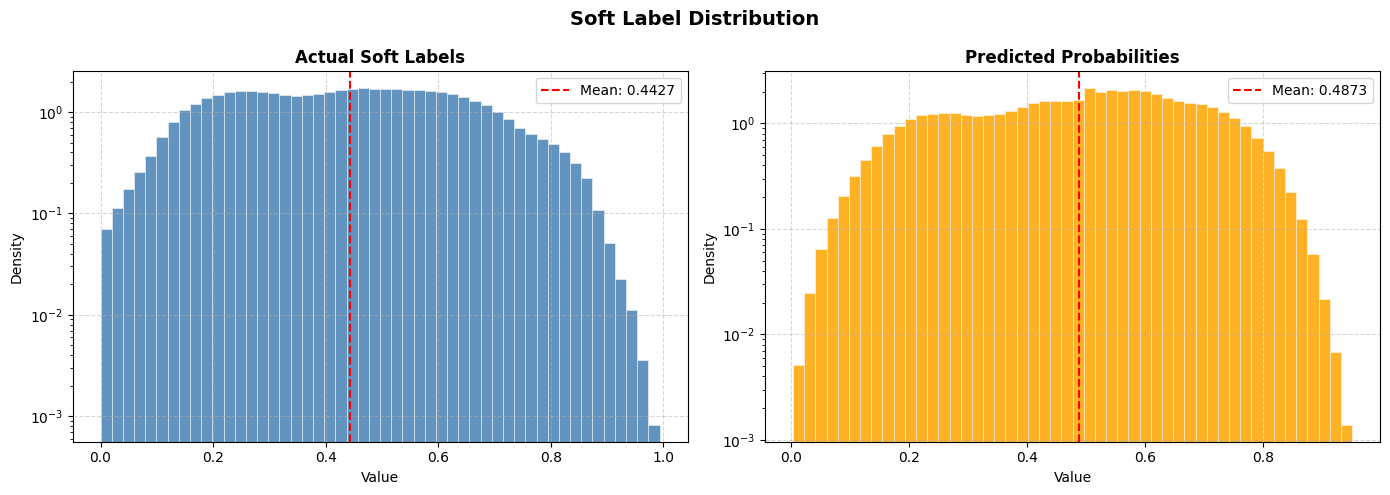

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Soft Label Distribution', fontsize=14, fontweight='bold')

actual = np.array(actual_soft_labels)
predicted = np.array(predicted_soft_labels)

# Actual
axes[0].hist(actual, bins=50, color='steelblue', alpha=0.85, density=True, edgecolor='white', linewidth=0.4)
axes[0].set_title('Actual Soft Labels', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_yscale('log')
axes[0].axvline(actual.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {actual.mean():.4f}')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Predicted
axes[1].hist(predicted, bins=50, color='orange', alpha=0.85, density=True, edgecolor='white', linewidth=0.4)
axes[1].set_title('Predicted Probabilities', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].set_yscale('log')
axes[1].axvline(predicted.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {predicted.mean():.4f}')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

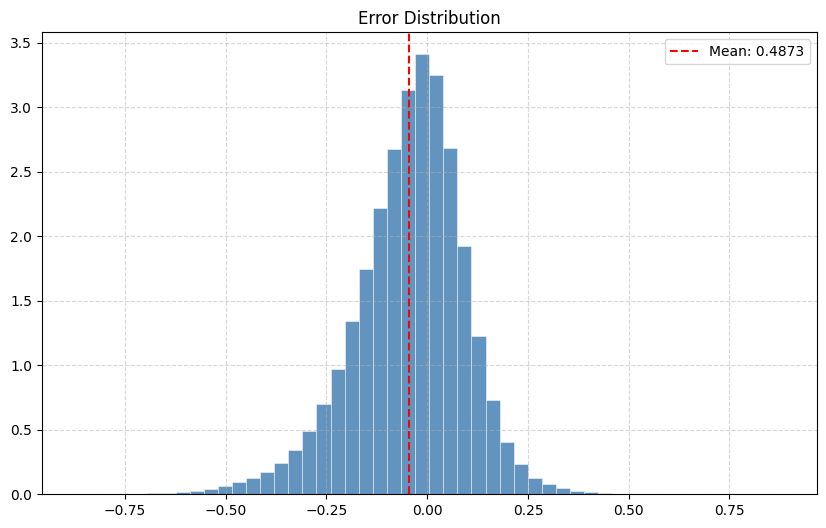

In [ ]:
error = actual - predicted
plt.figure(figsize=(10, 6))
plt.title('Error Distribution')
plt.hist(error, bins=50, color='steelblue', alpha=0.85, density=True, edgecolor='white', linewidth=0.4)
plt.axvline(error.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {predicted.mean():.4f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()